Determine HE scale here!
<br>
Solo utilizamos un run, hay que actualizar alrededor de ello.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image 
from scipy.optimize import curve_fit
from scipy.stats import linregress

# Styling Plot
crudo.pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Configuration

In [2]:
# ----- RUN SELECTION ----- #
RUN_ID = 15589

# -----------------------------------------
# 1. DIRECTORIES, PATHS, KEYS AND FILENAMES
# -----------------------------------------
VERSION_TAG = "th_zemrude"

INPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Th_analysis/h5/'

SUMMARY_FILENAME = 'summary_' + VERSION_TAG +'_processed.csv'     # Choose your name
SUMMARY_PATH = os.path.join('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Th_analysis/txt/summaries/', SUMMARY_FILENAME)

# KEYS
EVT_KEY = 'Events'
HIT_KEY = 'Hits'

# CUTFLOW: we need to think how to do it!
# CUT_NAMES = ['IC', 'Cleaning', 'One_S1', 'One_S2', 'Electron_like', 'Processed']

# --------------------------------
# 2. ALPHA/ELECTRON DISCRIMINATION
# --------------------------------
SIZE_THRESHOLD = 2e3          # in [# of hits]
S1_ENERGY_THRESHOLD = 900     # in [PE]

# -------------------
# 3. DETECTOR REGIONS
# -------------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# -----------------------------------------
# 4. REFERENCE PEAKS FOR ENERGY CALIBRATION
# -----------------------------------------
KNOWN_PEAKS_PES = {
                        "511 keV":   {'real_MeV': 0.511,  'guess': 98e3,  'range': (88e3, 108e3)},
                        "583 keV":   {'real_MeV': 0.583,  'guess': 113e3, 'range': (103e3, 123e3)},
                        "727 keV":   {'real_MeV': 0.727,  'guess': 141e3, 'range': (131e3, 151e3)},
                        "860 keV":   {'real_MeV': 0.860,  'guess': 167e3, 'range': (157e3, 177e3)},
                        "DE Peak":   {'real_MeV': 1.592,  'guess': 313e3, 'range': (293e3, 333e3)},
                        "Tl Peak":   {'real_MeV': 2.615,  'guess': 515e3, 'range': (495e3, 535e3)}
}

# Processed Data

Merge all the processed data!

In [3]:
all_processed_dfs = []      # Event/peak-level

# ----- LDC Loop ----- #
for ldc in range(1, 8):
    # Load the HDF5 file
    h5_path = os.path.join(INPUT_DIR, f'processed_run_{RUN_ID}_ldc{ldc}_{VERSION_TAG}_events.h5')
    if not os.path.exists(h5_path):
        print(f"Missing file for run {RUN_ID} ldc {ldc}. Skipping...")
        continue

    try:
        evt_df = pd.read_hdf(h5_path, key=EVT_KEY)
        all_processed_dfs.append(evt_df)

    except Exception as e:
        print(f"Error loading file for run {RUN_ID} ldc {ldc}: {e}")
        continue

MERGED_DF = pd.concat(all_processed_dfs, ignore_index=True)
print(f"\nRun {RUN_ID}:\n  Processed events = {MERGED_DF['event'].nunique()}")

Missing file for run 15589 ldc 5. Skipping...
Missing file for run 15589 ldc 6. Skipping...
Missing file for run 15589 ldc 7. Skipping...

Run 15589:
  Processed events = 436909


## Event Counters

Hay que pensarnos como gestionar los contadores, similares a _low background analysis_.

# Tagging Events

In [4]:
MERGED_DF

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S1e,main_S1e_corr,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q
0,8,37,184151.251888,208.391548,199.636433,727.221658,546.986210,1212.989933,502.019787,229390.528702,...,151.747345,202.112048,375.0,24.432436,752125.0,150070.453125,281.050,3798.209229,1417489.625,68422.437500
1,8,42,45239.276815,208.391548,199.636433,727.221658,546.986210,1212.989933,502.019787,229390.528702,...,151.747345,202.112048,375.0,24.432436,752125.0,150070.453125,281.050,3798.209229,1417489.625,68422.437500
2,29,39,321729.420232,115.279876,-392.414534,720.398541,652.442036,838.728004,487.977096,321729.420232,...,391.903259,488.807104,650.0,70.675652,604150.0,284933.000000,510.125,4855.565430,1409485.875,118341.734375
3,71,32,139708.645327,-45.606723,259.426141,550.984445,355.748117,1340.952626,390.691990,189897.958716,...,130.162003,195.454648,350.0,22.418476,981275.0,142723.734375,117.650,6206.925781,1413484.625,36185.945312
4,71,44,32864.037616,-45.606723,259.426141,550.984445,355.748117,1340.952626,390.691990,189897.958716,...,130.162003,195.454648,350.0,22.418476,981275.0,142723.734375,117.650,6206.925781,1413484.625,36185.945312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197233,3847180,21,74699.526434,366.565804,-9.981723,156.712854,110.394760,473.248096,491.099915,83874.758654,...,66.330864,118.759998,300.0,11.548846,1268400.0,70730.859375,231.600,8815.831055,1405492.375,44420.968750
197234,3847180,31,9175.232219,366.565804,-9.981723,156.712854,110.394760,473.248096,491.099915,83874.758654,...,66.330864,118.759998,300.0,11.548846,1268400.0,70730.859375,231.600,8815.831055,1405492.375,44420.968750
197235,3847187,11,12940.745505,214.445295,314.918458,454.716553,71.368122,547.285284,488.945218,105438.735575,...,89.450081,165.600427,275.0,17.838554,795875.0,82244.656250,214.000,5255.829590,1408484.875,41092.023438
197236,3847187,12,5309.708913,214.445295,314.918458,454.716553,71.368122,547.285284,488.945218,105438.735575,...,89.450081,165.600427,275.0,17.838554,795875.0,82244.656250,214.000,5255.829590,1408484.875,41092.023438


### By Particle

In [4]:
particle_tagged_MERGED_DF = crudo.dm.tag_particles(MERGED_DF, size_threshold=SIZE_THRESHOLD, s1_energy_threshold=S1_ENERGY_THRESHOLD, event_column='event')
particle_tagged_MERGED_DF

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S1e_corr,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q,particle
0,8,37,184151.251888,208.391548,199.636433,727.221658,546.986210,1212.989933,502.019787,229390.528702,...,202.112048,375.0,24.432436,752125.0,150070.453125,281.050,3798.209229,1417489.625,68422.437500,electron
1,8,42,45239.276815,208.391548,199.636433,727.221658,546.986210,1212.989933,502.019787,229390.528702,...,202.112048,375.0,24.432436,752125.0,150070.453125,281.050,3798.209229,1417489.625,68422.437500,electron
2,29,39,321729.420232,115.279876,-392.414534,720.398541,652.442036,838.728004,487.977096,321729.420232,...,488.807104,650.0,70.675652,604150.0,284933.000000,510.125,4855.565430,1409485.875,118341.734375,electron
3,71,32,139708.645327,-45.606723,259.426141,550.984445,355.748117,1340.952626,390.691990,189897.958716,...,195.454648,350.0,22.418476,981275.0,142723.734375,117.650,6206.925781,1413484.625,36185.945312,electron
4,71,44,32864.037616,-45.606723,259.426141,550.984445,355.748117,1340.952626,390.691990,189897.958716,...,195.454648,350.0,22.418476,981275.0,142723.734375,117.650,6206.925781,1413484.625,36185.945312,electron
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789978,3847120,40,22487.736240,-239.182648,-275.245123,984.764716,836.743802,1624.011334,482.559075,291678.607591,...,390.472798,750.0,58.403679,316950.0,230803.375000,210.425,4516.109863,1400490.625,67099.335938,electron
789979,3847148,33,143958.476520,-99.374798,-59.196209,884.115294,846.219444,1191.649626,465.046967,150806.437851,...,195.124798,500.0,28.257397,413050.0,145755.265625,187.525,4390.946777,1410489.625,46733.781250,electron
789980,3847148,38,6847.961331,-99.374798,-59.196209,884.115294,846.219444,1191.649626,465.046967,150806.437851,...,195.124798,500.0,28.257397,413050.0,145755.265625,187.525,4390.946777,1410489.625,46733.781250,electron
789981,3847155,31,285811.947198,205.931668,-19.233901,1091.900913,937.904363,1844.555410,456.685298,333109.650645,...,362.620657,475.0,59.148529,304150.0,286948.125000,174.000,6497.146484,1413484.250,76176.062500,electron


### By Detector Region

In [5]:
region_tagged_MERGED_DF = crudo.dm.tag_event_by_detector_region(particle_tagged_MERGED_DF, z_cut_low=Z_LOW, z_cut_high=Z_UP, r_cut_high=R_UP, event_column='event')
region_tagged_MERGED_DF

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q,particle,region
0,8,37,184151.251888,208.391548,199.636433,727.221658,546.986210,1212.989933,502.019787,229390.528702,...,375.0,24.432436,752125.0,150070.453125,281.050,3798.209229,1417489.625,68422.437500,electron,cathode
1,8,42,45239.276815,208.391548,199.636433,727.221658,546.986210,1212.989933,502.019787,229390.528702,...,375.0,24.432436,752125.0,150070.453125,281.050,3798.209229,1417489.625,68422.437500,electron,cathode
2,29,39,321729.420232,115.279876,-392.414534,720.398541,652.442036,838.728004,487.977096,321729.420232,...,650.0,70.675652,604150.0,284933.000000,510.125,4855.565430,1409485.875,118341.734375,electron,tube
3,71,32,139708.645327,-45.606723,259.426141,550.984445,355.748117,1340.952626,390.691990,189897.958716,...,350.0,22.418476,981275.0,142723.734375,117.650,6206.925781,1413484.625,36185.945312,electron,cathode
4,71,44,32864.037616,-45.606723,259.426141,550.984445,355.748117,1340.952626,390.691990,189897.958716,...,350.0,22.418476,981275.0,142723.734375,117.650,6206.925781,1413484.625,36185.945312,electron,cathode
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789978,3847120,40,22487.736240,-239.182648,-275.245123,984.764716,836.743802,1624.011334,482.559075,291678.607591,...,750.0,58.403679,316950.0,230803.375000,210.425,4516.109863,1400490.625,67099.335938,electron,cathode
789979,3847148,33,143958.476520,-99.374798,-59.196209,884.115294,846.219444,1191.649626,465.046967,150806.437851,...,500.0,28.257397,413050.0,145755.265625,187.525,4390.946777,1410489.625,46733.781250,electron,cathode
789980,3847148,38,6847.961331,-99.374798,-59.196209,884.115294,846.219444,1191.649626,465.046967,150806.437851,...,500.0,28.257397,413050.0,145755.265625,187.525,4390.946777,1410489.625,46733.781250,electron,cathode
789981,3847155,31,285811.947198,205.931668,-19.233901,1091.900913,937.904363,1844.555410,456.685298,333109.650645,...,475.0,59.148529,304150.0,286948.125000,174.000,6497.146484,1413484.250,76176.062500,electron,cathode


# Fiducial Electrons

We first perform the $nS1 = nS2 = 1$ selection cut, plot spatial distribution and then select fiducial events to analyze the event energy.

## Pulse Multiplicity

In [6]:
# --- nS1 = nS2 = 1 --- #
# This is a event-level dataframe as there is no peak multiplicity
EVENT_DF = region_tagged_MERGED_DF[region_tagged_MERGED_DF['nS1'] == 1].copy()
EVENT_DF = EVENT_DF[EVENT_DF['nS2'] == 1].copy()
EVENT_DF

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q,particle,region
2,29,39,3.217294e+05,115.279876,-392.414534,720.398541,652.442036,838.728004,487.977096,3.217294e+05,...,650.0,70.675652,604150.0,284933.000000,510.125,4855.565430,1409485.875,118341.734375,electron,tube
9,120,32,3.460808e+05,264.252737,-140.657555,572.703536,510.001729,651.456801,456.387901,3.460808e+05,...,675.0,56.735172,790500.0,347422.250000,325.700,5438.912598,1457495.875,104431.320312,electron,tube
17,309,25,5.126339e+05,-282.122286,167.523130,777.152376,601.435041,1016.024567,498.053091,5.126339e+05,...,400.0,94.684158,696125.0,452668.531250,566.700,5074.413086,1410496.000,156294.125000,electron,tube
20,358,27,7.824008e+04,-285.362207,-247.606983,178.415272,169.475125,192.710863,462.412582,7.824008e+04,...,275.0,10.520331,1199650.0,77638.617188,110.100,6464.333008,1405486.750,23629.761719,electron,tube
21,393,27,4.143669e+05,56.173005,126.552494,718.325607,618.187063,807.841773,460.597646,4.143669e+05,...,750.0,78.846909,615800.0,419810.875000,468.450,5077.400879,1414481.750,134321.562500,electron,tube
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789963,3846721,27,9.669622e+04,279.052063,287.854482,538.019179,522.657977,553.148686,478.588582,9.669622e+04,...,325.0,15.982276,785175.0,89400.062500,155.000,5250.630371,1409494.875,35595.527344,electron,tube
789969,3846847,23,1.171163e+06,-308.707456,152.194872,731.714061,719.207926,749.720369,561.092819,1.171163e+06,...,350.0,220.293213,569075.0,943926.875000,204.525,64754.652344,1414489.250,220057.890625,alpha,tube
789970,3846861,16,3.326529e+05,61.726454,304.169212,598.736159,550.565472,684.714213,471.646792,3.326529e+05,...,700.0,54.261124,758125.0,328372.562500,290.050,7217.056152,1420484.000,89636.500000,electron,tube
789971,3846938,38,1.599133e+05,211.900098,298.236540,295.813696,279.951628,334.402404,476.641612,1.599133e+05,...,675.0,18.906973,1073050.0,154440.625000,152.775,6921.602051,1405489.125,43481.757812,electron,tube


### Spatial Distributions

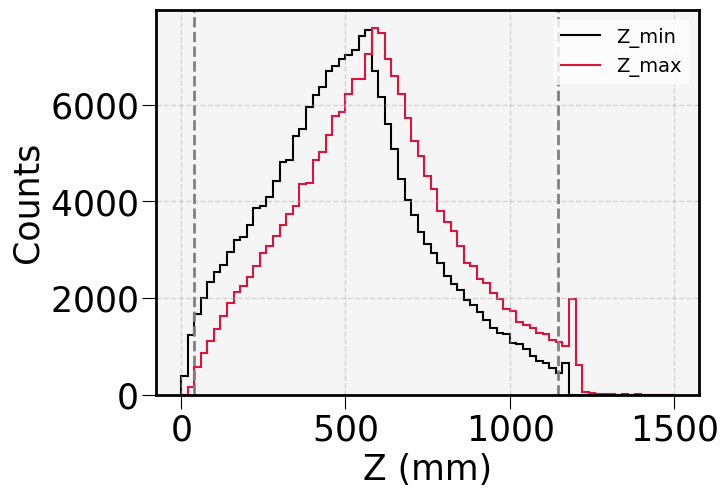

In [7]:
# Global
n_bins = 75
plt.figure(figsize=(7, 5))

# ----- Define the Binning ----- #
_, Z_edges = np.histogram(EVENT_DF['Z_bary'], bins=n_bins, range=(0, 1500))

for i, var in enumerate(['Z_min', 'Z_max']):

        Z_counts, _ = np.histogram(EVENT_DF[var], bins=Z_edges)

        # ----- Plotting ----- #
        plt.stairs(Z_counts, Z_edges, label=f'{var}',
                   fill=False, lw=1.5, ec=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)])

# Z-limits
plt.axvline(x=Z_LOW, c='grey', ls='--')
plt.axvline(x=Z_UP, c='grey', ls='--')
        
# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.ylabel('Counts')
plt.legend(loc='upper right', fontsize=14)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

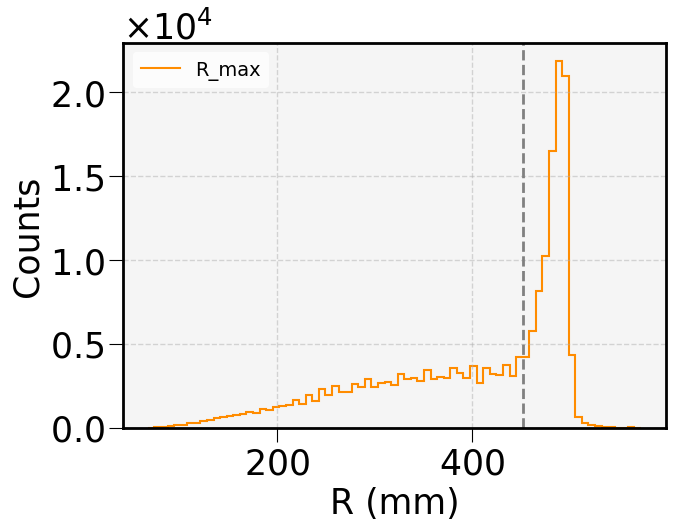

In [8]:
# Global
n_bins = 75
plt.figure(figsize=(7, 5))

R_counts, R_edges = np.histogram(EVENT_DF['R_max'], bins=n_bins)
# ----- Plotting ----- #
plt.stairs(R_counts, R_edges, label='R_max',
           fill=False, lw=1.5, ec=crudo.pt.hist_colors[2])

# R-limit
plt.axvline(x=R_UP, c='grey', ls='--')
        
# ----- Styling ----- #
plt.xlabel('R (mm)')
plt.ylabel('Counts')
plt.legend(loc='upper left', fontsize=14)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

# Fiducial Volume

In [9]:
FIDU_EVT_DF = EVENT_DF[EVENT_DF['region'] == 'fiducial'].copy()

print(f'----- Fiducial Volume Selection -----')
print(f'Fiducial events = {FIDU_EVT_DF["event"].nunique()} ({FIDU_EVT_DF["event"].nunique() / EVENT_DF["event"].nunique():.2%})')

----- Fiducial Volume Selection -----
Fiducial events = 106688 (52.48%)


In [27]:
FIDU_EVT_DF

,event,npeak,E_peak_pe,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,...,main_S1w,main_S1h,main_S1t,main_S2e,main_S2w,main_S2h,main_S2t,main_S2q,particle,region
22,400,27,193307.952208,-121.063559,-59.872123,1066.240583,1039.190564,1100.854576,282.408961,193307.952208,...,625.0,40.804302,188000.0,200394.265625,427.250,4814.290527,1415495.125,92607.203125,electron,fiducial
23,442,32,65235.042778,140.067025,42.717566,791.006490,776.658956,831.505470,205.623044,65235.042778,...,525.0,13.394168,497525.0,67065.500000,216.350,3785.974609,1405486.250,37907.949219,electron,fiducial
34,687,21,337223.848706,211.556573,-219.231373,708.276679,643.954656,774.799746,392.766357,337223.848706,...,725.0,60.658051,624925.0,339142.000000,269.350,5351.426270,1411479.500,90060.789062,electron,fiducial
38,729,30,142056.973385,-304.287688,26.900680,1022.566372,986.863146,1048.540458,391.948697,142056.973385,...,825.0,31.553558,210475.0,142254.812500,197.800,3983.655762,1405485.875,46304.746094,electron,fiducial
50,883,18,70047.518092,-268.155482,-61.312510,794.495613,783.623827,807.088899,341.234555,70047.518092,...,525.0,17.248856,489500.0,72588.984375,207.450,4508.593262,1408493.625,37770.585938,electron,fiducial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197192,3846403,33,425454.727505,201.858930,-12.174788,297.305821,173.057198,455.561873,369.409957,425454.727505,...,575.0,67.333649,1191875.0,438226.656250,588.775,7870.316406,1408479.250,152493.593750,electron,fiducial
197198,3846508,30,114625.520017,119.765275,296.214206,385.919864,363.690764,425.073110,404.720251,114625.520017,...,425.0,22.129530,974150.0,114436.742188,426.775,5176.363281,1405488.625,77249.765625,electron,fiducial
197201,3846571,22,201480.953860,-185.548580,-190.583756,917.837303,885.452168,960.990564,352.531518,201480.953860,...,750.0,40.982895,366800.0,203352.562500,207.050,5492.810059,1409487.750,63516.789062,electron,fiducial
197219,3846823,37,67293.521382,-305.595443,16.903857,286.150898,278.605904,315.639257,374.672559,67293.521382,...,300.0,9.439380,1079400.0,68953.992188,418.000,6137.125488,1406488.375,67754.843750,electron,fiducial


How does the energy look?

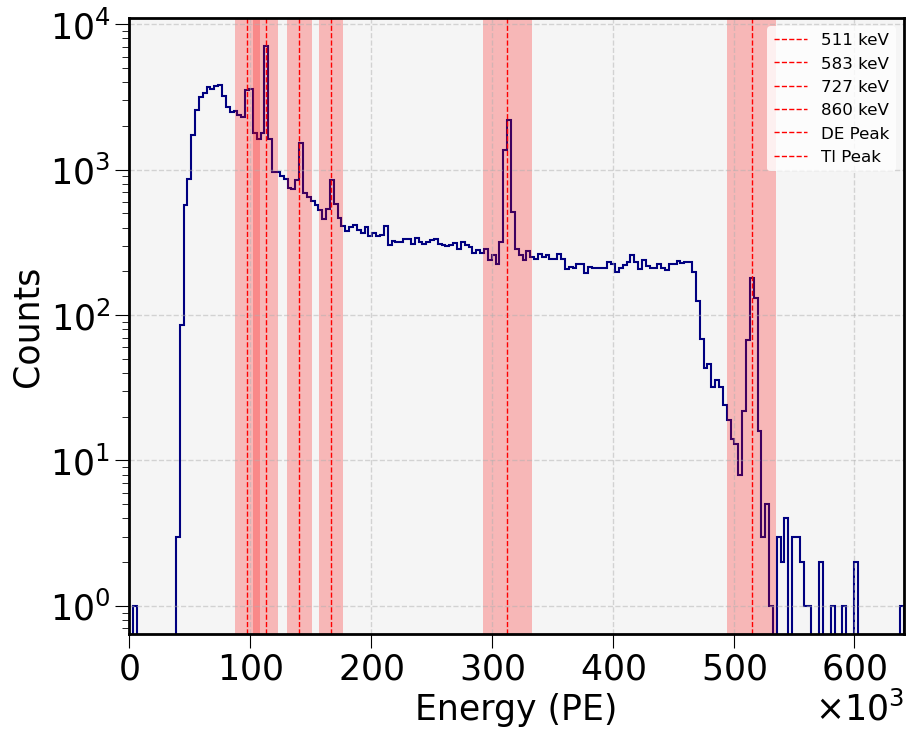

In [11]:
# Global
n_bins = 200
# plt.figure(figsize=(7, 5))

E_counts, E_edges = np.histogram(FIDU_EVT_DF['E_evt_pe'], bins=n_bins)
# ----- Plotting ----- #
plt.stairs(E_counts, E_edges,
           fill=False, lw=1.5, ec=crudo.pt.hist_colors[5])

# Reference peaks
for peak_name, peak_info in KNOWN_PEAKS_PES.items():
    plt.axvline(x=peak_info['guess'], c='red', ls='--', lw=1.0, label=peak_name)
    plt.axvspan(peak_info['range'][0], peak_info['range'][1], color='red', ec=None, alpha=0.25)
        
# ----- Styling ----- #
plt.xlabel('Energy (PE)')
plt.xlim(0, E_edges[-1])
plt.ylabel('Counts')
plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(loc='upper right', fontsize=12)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

# Energy Analysis

### Helper Functions

In [12]:
# --- Fitting Functions --- #
# def gaus_with_linear_bg(x, amplitude, mu, sigma, slope, intercept):
#     '''
#     A Gaussian peak with a sloped, linear background
#     '''
#     # Failsafe for sigma
#     sigma = max(abs(sigma), 1e-9)

#     gauss_part = amplitude * np.exp(-(x - mu)**2 / (2 * sigma**2))
#     linear_part = slope * x + intercept

#     return gauss_part + linear_part

def crystal_ball_with_linear_bg(x, amplitude, mu, sigma, alpha, n, slope, intercept):
    '''
    Crystal Ball function with a linear background.
    '''
    # Failsafes for stability
    n = max(n, 1e-9)
    sigma = max(abs(sigma), 1e-9)
    alpha = max(alpha, 1e-9)

    t = (x - mu) / sigma
    
    # Gaussian part
    gauss = amplitude * np.exp(-0.5 * t**2)
    
    # Power-law tail part
    A = (n / abs(alpha))**n * np.exp(-0.5 * alpha**2)
    B = n / abs(alpha) - abs(alpha)
    tail = amplitude * A * (B - t)**(-n)
    
    # Combine using masks
    cb_shape = np.where(t > -alpha, gauss, tail)
    
    return cb_shape + (slope * x + intercept)

def fit_peak_crystal_ball(data, mu_guess, fit_range, bins='auto'):
    '''
    Fits a Crystal Ball + linear background to a peak.
    '''
    y, bin_edges = np.histogram(data, bins=bins, range=fit_range)
    x = (bin_edges[:-1] + bin_edges[1:]) / 2

    if np.sum(y) < 50: 
        return None, None, (x, y)
    
    # Smart guesses
    slope_guess     = (np.mean(y[-5:]) - np.mean(y[:5])) / (x[-1] - x[0])
    intercept_guess = np.mean(y[:5]) - slope_guess * x[0]
    amplitude_guess = y.max() - (slope_guess * mu_guess + intercept_guess)
    sigma_guess = (fit_range[1] - fit_range[0]) / 10
    
    # Crystal ball specific guesses: alpha controls where tail starts, n controls shape
    alpha_guess = 1.0 
    n_guess = 2.0
    
    p0 = [amplitude_guess, mu_guess, sigma_guess, alpha_guess, n_guess, slope_guess, intercept_guess]

    try:
        popt, pcov = curve_fit(crystal_ball_with_linear_bg, x, y, p0=p0, sigma=np.sqrt(np.maximum(y, 1)))
        return popt, pcov, (x, y)
    except (RuntimeError, ValueError) as e:
        print(f"   Fit failed for peak near {mu_guess:.1f}. Reason: {e}")
        return None, None, (x, y)

# --- Calibration Pipeline --- #
def calibrate_pes_to_MeV_and_get_resolution(
                                                event_energies_df: pd.DataFrame,    # Expects energy in PE
                                                known_peaks_pes: dict               # Dictionary with guesses/ranges in PE
):
    """
    A full pipeline that:
    1. Fits peaks in the uncalibrated 'pes' spectrum.
    2. Determines the linear pes -> MeV calibration.
    3. Applies the calibration.
    4. Re-fits the peaks in the calibrated MeV spectrum to find the resolution.
    """
    print(f"\n{'='*20} Running PE → MeV Calibration {'='*20}")
    initial_energies_pes = event_energies_df['E_evt_pe']
    
    # ----- STAGE 01: Initial Fits in PE ----- #
    print("\nSTAGE 01: Fitting uncalibrated peaks to find positions in PE...")
    fig_init, axes_init = plt.subplots(int(np.ceil(len(known_peaks_pes)/2)), 2, figsize=(16, 5*np.ceil(len(known_peaks_pes)/2)))
    axes_init = axes_init.flatten()
    plt.suptitle(f'Initial Peak Fits (in PE)', fontsize=25, y=0.94)

    initial_fit_results = []
    for i, (peak_name, props) in enumerate(known_peaks_pes.items()):
        ax = axes_init[i]
        # --- Fitting
        popt, pcov, hist_data = fit_peak_crystal_ball(initial_energies_pes, props['guess'], props['range'], bins=props.get('bins', 'auto'))
        # --- Plotting
        # Data
        ax.step(hist_data[0], hist_data[1], where='mid', label='Data')
        if popt is not None:
            # Fit
            fit_x = np.linspace(props['range'][0], props['range'][1], 300)
            ax.plot(fit_x, crystal_ball_with_linear_bg(fit_x, *popt), 'r-', label='Fit')
            # Results
            mu, mu_err = popt[1], np.sqrt(pcov[1, 1])
            ax.text(0.025, 0.95, f'μ = ({mu:.1f} ± {mu_err:.1f}) PE', transform=ax.transAxes, va='top', fontsize=14)
            initial_fit_results.append({'name': peak_name, 'real_E_MeV': props['real_MeV'], 'measured_E_pes': mu, 'measured_E_err_pes': mu_err})
        # --- Styling
        ax.set_title(f'→ {peak_name}')
        ax.set_xlabel('Measured Energy (PE)')
        ax.set_ylim(hist_data[1].min(), 1.25*hist_data[1].max())
        ax.legend(fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    # ----- STAGE 02: Energy Scale (MeV vs. PE) ----- #
    fit_df = pd.DataFrame(initial_fit_results)
    if len(fit_df) < 2:
        print("Not enough successful fits to perform calibration. Aborting."); return None
    
    # Fit: Nominal Energy (MeV) = m * Measured Energy (PE) + n
    calib_fit = linregress(fit_df['measured_E_pes'], fit_df['real_E_MeV'])      # From here we can extract linear fit information
    m_calib, b_calib = calib_fit.slope, calib_fit.intercept
    calib_results = [{'m_cv': m_calib, 'm_err': calib_fit.stderr, 'b_cv': b_calib, 'b_err': calib_fit.intercept_stderr, 'r_value': calib_fit.rvalue}]
    print(f"\nStage 02: Calibration → E_MeV = {m_calib:.2e} * E_PE + {b_calib:.4f}")

    # --- Plotting
    fig_calib, ax_calib = plt.subplots(figsize=(7, 5))
    # Data
    ax_calib.errorbar(fit_df['measured_E_pes'], fit_df['real_E_MeV'], xerr=fit_df['measured_E_err_pes'], fmt='o', lw=1.0, label='Fitted Peaks')
    # Fit
    x_fit = np.array([0, fit_df['measured_E_pes'].max() * 1.1]); y_fit = m_calib * x_fit + b_calib
    ax_calib.plot(x_fit, y_fit, 'b--', label=f'Fit')
    # --- Styling
    ax_calib.set_xlabel('Measured Peak Energy (PE)')
    ax_calib.set_ylabel('Real Peak Energy (MeV)')
    ax_calib.legend(fontsize=12)
    ax_calib.grid(True)
    plt.show()

    # ----- STAGE 03: Apply Calibration ----- #
    print("\nStage 03: Applying calibration, going from PE to MeV...")
    calibrated_energies_MeV = m_calib * initial_energies_pes + b_calib
    
    # ----- STAGE 04: Final Fits in MeV ----- #
    print("\nStage 4: Computing final energy resolution...")
    fig_final, axes_final = plt.subplots(int(np.ceil(len(known_peaks_pes)/2)), 2, figsize=(16, 5*np.ceil(len(known_peaks_pes)/2)))
    axes_final = axes_final.flatten()
    fig_final.suptitle(f'Final Resolution Fits (in MeV)', fontsize=25, y=0.94)

    final_resolution_results = []
    for i, (peak_name, props) in enumerate(known_peaks_pes.items()):
        ax = axes_final[i]
        # --- Fitting
        real_E = props['real_MeV']
        calib_range = (real_E - 0.05, real_E + 0.05)    # Define fit range in calibrated MeV
        popt, pcov, hist_data = fit_peak_crystal_ball(calibrated_energies_MeV, real_E, calib_range, bins=props.get('bins', 'auto'))
        
        # --- Plotting
        # Data
        ax.step(hist_data[0], hist_data[1], where='mid', label='Data')
        if popt is not None:
            # Fit
            fit_x = np.linspace(calib_range[0], calib_range[1], 300)
            ax.plot(fit_x, crystal_ball_with_linear_bg(fit_x, *popt), 'r-', label='Fit')
            # Results
            mu, sigma = popt[1], abs(popt[2])
            mu_err, sigma_err = np.sqrt(pcov[1, 1]), np.sqrt(pcov[2, 2])
            res_cv  = 2.355 * sigma / mu * 100
            res_err = res_cv * np.sqrt((sigma_err/sigma)**2 + (mu_err/mu)**2) if sigma > 0 else np.nan
            ax.text(0.025, 0.95, f'μ = ({mu:.4f} ± {mu_err:.4f}) MeV\nR(%) = {res_cv:.2f} ± {res_err:.2f}', transform=ax.transAxes, va='top', fontsize=14)
            final_resolution_results.append({'peak': peak_name, 'resolution_(FWHM)': res_cv, 'resolution_error': res_err})
        # --- Styling         
        ax.set_title(f'→ {peak_name}')
        ax.set_xlabel('Calibrated Energy (MeV)')
        ax.set_ylim(hist_data[1].min(), 1.25*hist_data[1].max())
        ax.legend(fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    return pd.DataFrame(calib_results), pd.DataFrame(final_resolution_results)

### Execution


==================== Running PE → MeV Calibration ====================

STAGE 01: Fitting uncalibrated peaks to find positions in PE...


/tmp/ccortesp/ipykernel_2601339/2293378241.py:31: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)
/tmp/ccortesp/ipykernel_2601339/2293378241.py:31: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)
/tmp/ccortesp/ipykernel_2601339/2293378241.py:31: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)
/lhome/ific/c/ccortesp/.local/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/tmp/ccortesp/ipykernel_2601339/2293378241.py:31: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)
/tmp/ccortesp/ipykernel_2601339/2293378241.py:31: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)
/tmp/ccortesp/ipykernel_2601339/2293378241.py:29: RuntimeWarning: o

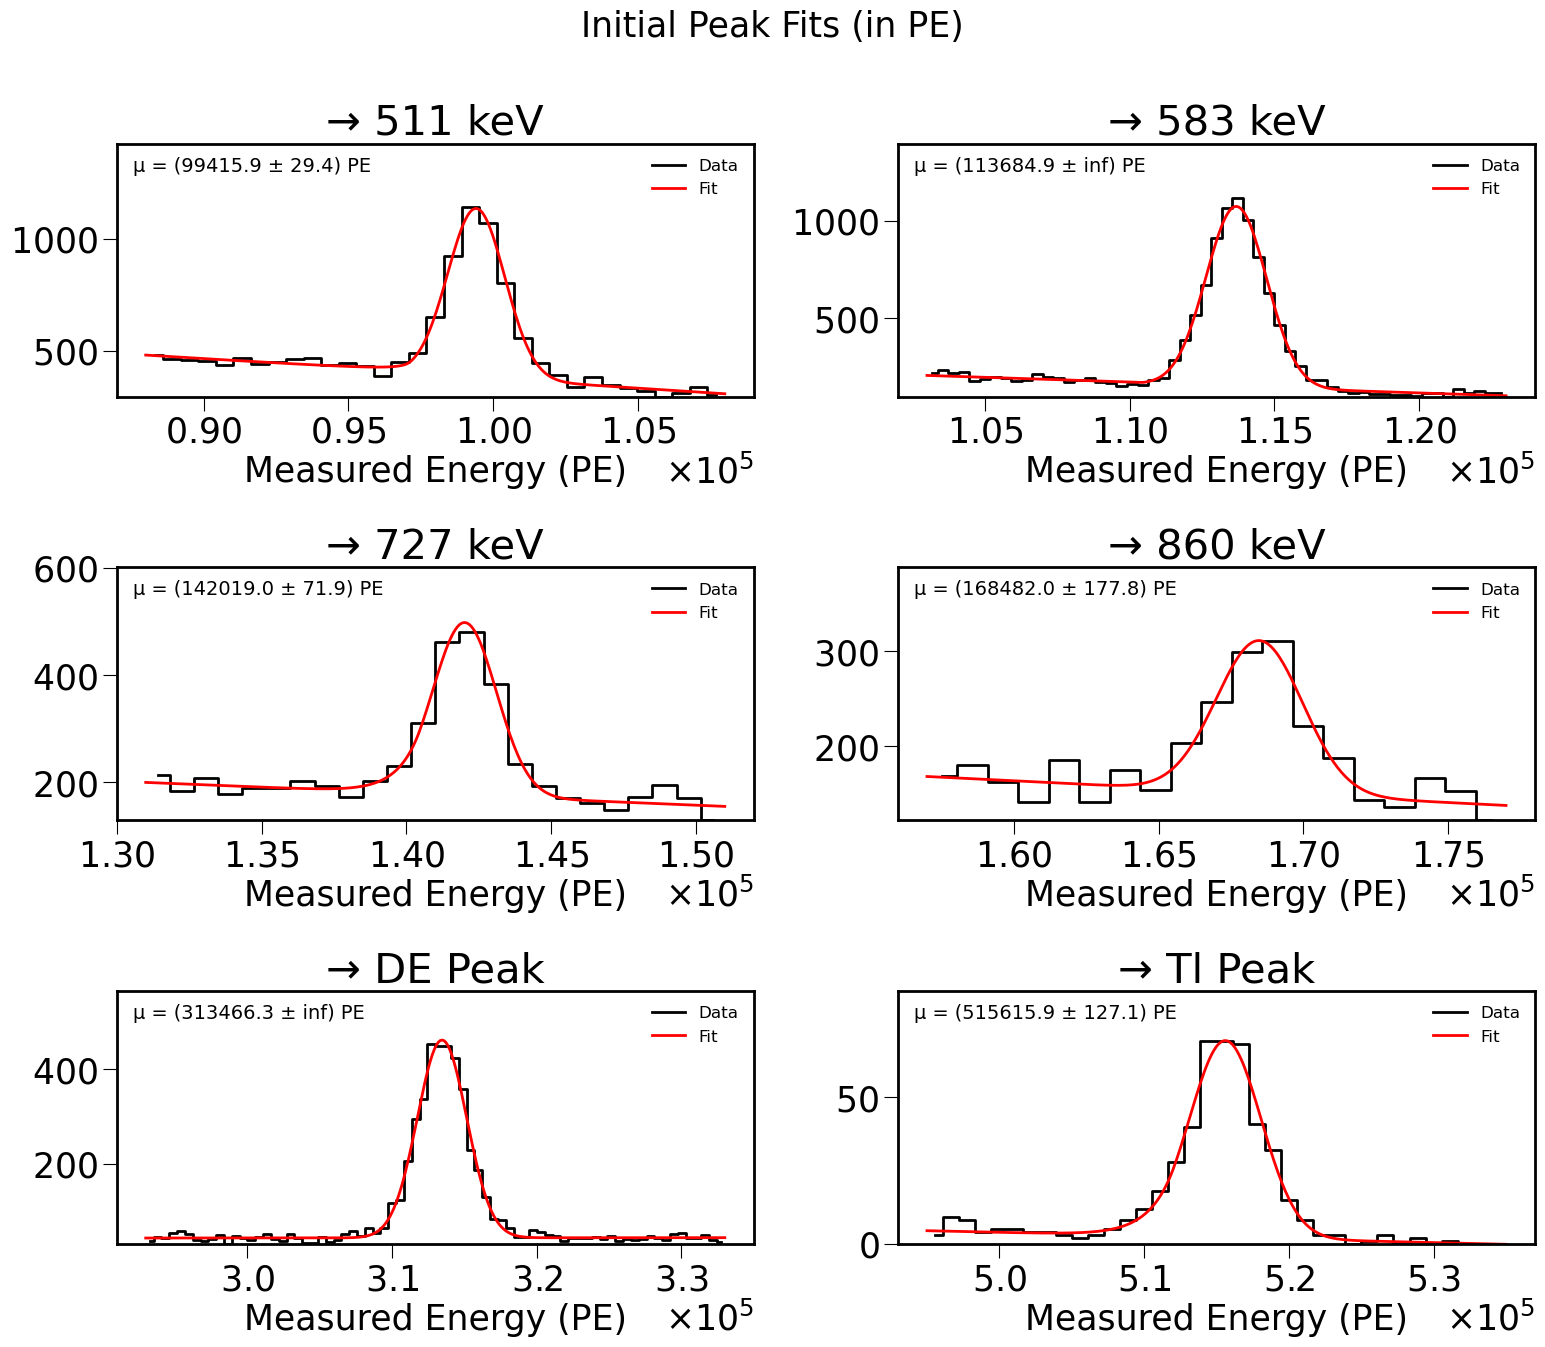


Stage 02: Calibration → E_MeV = 5.05e-06 * E_PE + 0.0085


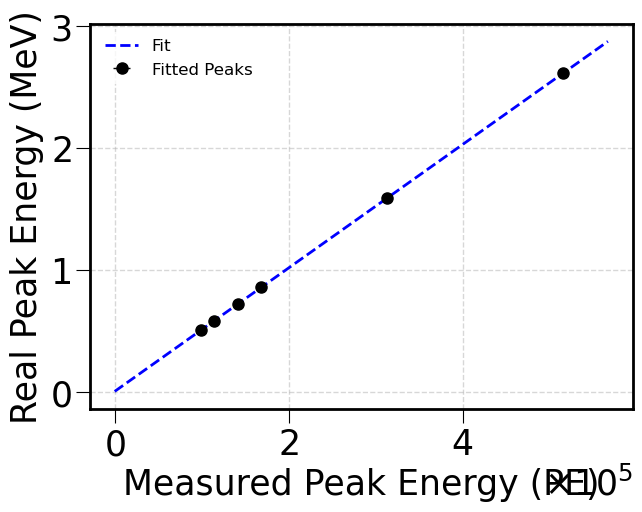


Stage 03: Applying calibration, going from PE to MeV...

Stage 4: Computing final energy resolution...


/tmp/ccortesp/ipykernel_2601339/2293378241.py:31: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)
/tmp/ccortesp/ipykernel_2601339/2293378241.py:31: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)
/tmp/ccortesp/ipykernel_2601339/2293378241.py:31: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)
/lhome/ific/c/ccortesp/.local/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/tmp/ccortesp/ipykernel_2601339/2293378241.py:31: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)
/tmp/ccortesp/ipykernel_2601339/2293378241.py:31: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)
/lhome/ific/c/ccortesp/.local/lib/python3.8/site-packages/scipy/opt

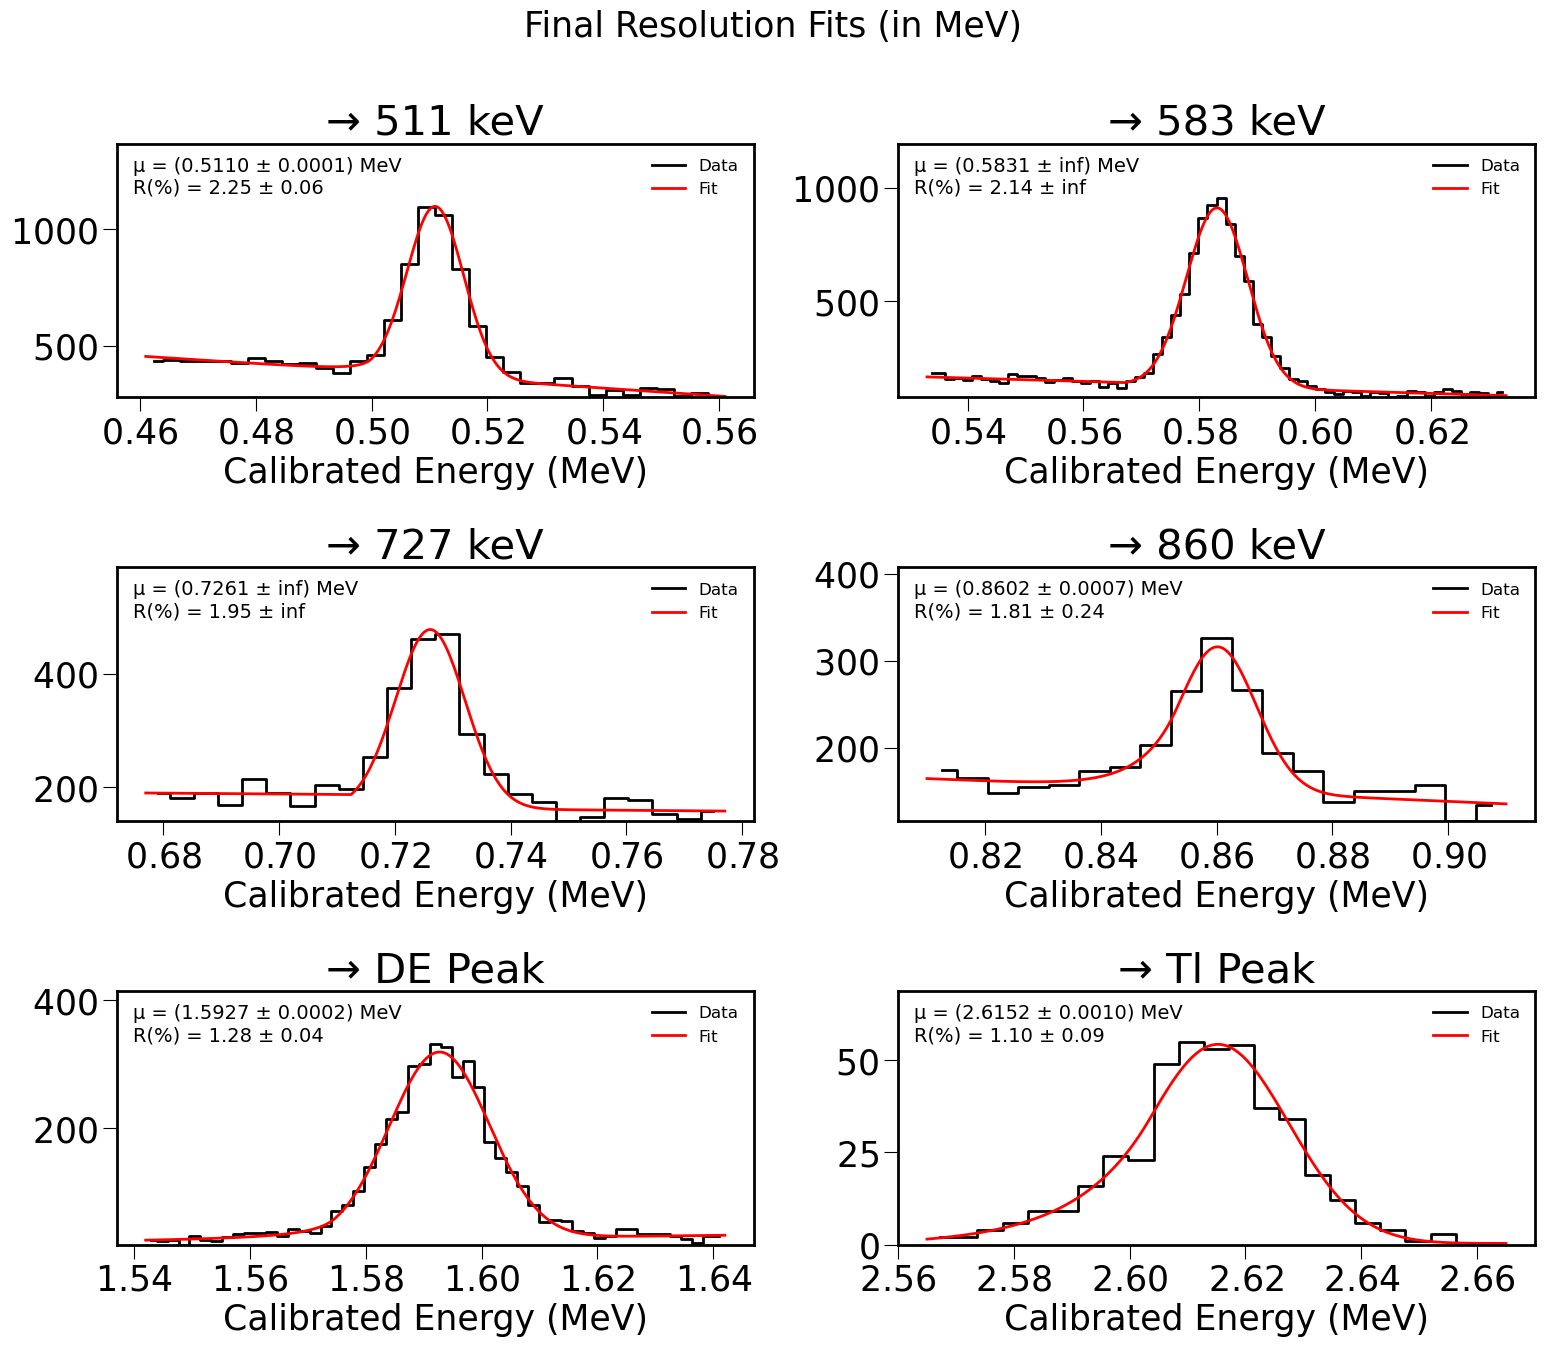


----- Final Summary -----
       m_cv         m_err      b_cv     b_err  r_value
0  0.000005  1.636069e-09  0.008519  0.000441      1.0
      peak  resolution_(FWHM)  resolution_error
0  511 keV           2.254599          0.064268
1  583 keV           2.141043               inf
2  727 keV           1.950205               inf
3  860 keV           1.814227          0.235967
4  DE Peak           1.279472          0.035452
5  Tl Peak           1.099848          0.089849


In [13]:
calibration_table, resolution_table = calibrate_pes_to_MeV_and_get_resolution(
                                                                                    event_energies_df=FIDU_EVT_DF,
                                                                                    known_peaks_pes=KNOWN_PEAKS_PES
                                                                             )

print("\n----- Final Summary -----")
print(calibration_table)
print(resolution_table)